# XAIKit Full Workflow Tutorial

This notebook runs the complete workflow for designing an XAI experiment, training an AI model, generating explanations, building trial tables, and simulating cognitive-model outputs.

The helper logic lives in `tutorials/utils.py`; the notebook cells stay focused on the workflow steps.


## 0. Setup (in the future will be just import [xaikit-test])

Import repository APIs and workflow helpers. The dataset is loaded through `src.data_loaders`, not by reading raw CSV paths in the notebook.


In [1]:
# Step 0: import notebook dependencies and repository workflow helpers.
# `Path` is used for local artifact paths; NumPy/Pandas handle arrays and tabular previews.
from pathlib import Path

import numpy as np
import pandas as pd

# Import high-level helpers from tutorials/utils.py so the notebook stays workflow-focused.
from utils import (
    combine_explanation_tables,  # Merge per-method explanation CSVs into one design-engine table.
    default_cognitive_params,  # Start from a standard cognitive-parameter dictionary.
    ensure_project_imports,  # Add the repository root to sys.path when running from tutorials/.
    generate_xai_explanation_tables,  # Generate one explanation table per configured XAI method.
    generate_experimental_trials,  # Build/export/preview trial rows from a TrialBuildConfig.
    generate_trials_from_ui_json,  # Optional path for regenerating trials from a UI JSON export.
    init_experiment_config,  # Create empty IV/CV/DV dictionaries for iterative configuration.
    init_explanation_run,  # Bundle explanation-generation settings into one config object.
    init_trial_build_config,  # Bundle trial-generation settings into one config object.
    load_csv_records,  # Read CSV artifacts as dictionaries when needed.
    load_explanation_pool,  # Load generated explanations for cognitive simulation.
    load_json_config,  # Read JSON configuration artifacts when needed.
    prepare_dataset,  # Load, optionally feature-filter, and split a dataset.
    run_experiment_executor,  # Apply the cognitive simulation over trial rows.
    save_simulated_results,  # Persist simulated outputs as CSV/JSON.
    set_factor,  # Add one CV or DV factor to its dictionary.
    set_iv,  # Add one independent variable to the experiment design.
    validate_experiment_config,  # Validate and print the IV/CV/DV configuration.
)

# Make repository modules importable before importing src.* packages.
ensure_project_imports()

# ModelManager is the public AI-model API used to create, train, evaluate, and expose models.
from src.ai_models import ModelManager
# XAI visualization helpers live with the XAI adapter package.
from src.xai_adapter import plot_explanation_visual


## 1. Configure Experimental Design

Define independent variables (IVs), control variables (CVs), and dependent variables (DVs).


In [ ]:
# Step 1: define the experimental design.
# IVs are manipulated variables, CVs are controlled/recorded variables, and DVs are measured outputs.
iv_config, CVs, DVs = init_experiment_config()

# Add independent variables.
# name="xai_method": between-subjects factor; each participant sees one method level.
set_iv(iv_config, "xai_method", "between", ["shap", "lime", "none"])
# name="tested_w_xai": within-subjects factor randomized at the trial level.
set_iv(iv_config, "tested_w_xai", "within", [True, False], randomization="trial")

# Add controlled variables.
# These become metadata columns on generated trial rows rather than experimental manipulations.
set_factor(CVs, "age_group", ["young", "adult", "senior"])
set_factor(CVs, "gender", ["male", "female"])

# Add dependent variables.
# These names tell the cognitive executor which outputs should appear in simulated results.
set_factor(DVs, "forward_accuracy", ["continuous"])

# Validate the design and print a compact summary for the notebook reader.
validate_experiment_config(iv_config, CVs, DVs)


## 2. Load Dataset Through `src.data_loaders`

Use one workflow helper to load through the repository dataloader, create a stable split, and keep dataset artifacts together.


In [3]:
# Step 2: load, rank features, and split the dataset through the repository data loader.
# Feature order is ranked by absolute correlation with the target before training and explanation generation.
# `prepare_dataset` returns one PreparedDataset object containing raw data, model matrices, labels, and instance ids.

# Optional feature-selection example.
# Uncomment this block to rank only these candidate wine-quality columns, then keep the first 5.
# data = prepare_dataset(
#     "wine_quality",  # Dataset id listed by src.data_loaders.
#     feature_cols=["Alcohol", "Sulphates", "SO2", "Vinegar Taint", "citric acid"],  # Candidate feature names.
#     num_features=5,  # Keep the first 5 after target-correlation ranking.
#     rank_features_by_target=True,  # Rank candidates by absolute correlation with y before slicing/training.
#     test_size=0.2,  # Hold out 20% of rows for test/trial sampling.
#     random_state=42,  # Reproducible split.
# )

data = prepare_dataset(
    "wine_quality",  # Dataset id to load.
    rank_features_by_target=True,  # Rank all features by target correlation before training/explanations.
    test_size=0.2,  # Fraction of rows reserved for test/trial sampling.
    random_state=123,  # Reproducible train/test split.
)


Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 11 model features)
Features  : ['Alcohol', 'Vinegar Taint', 'citric acid', 'Sulphates', 'density', 'SO2', 'fixed acidity', 'chlorides', 'free sulfur dioxide', 'pH', 'residual sugar']
Train set : 1279 samples  (80%)
Test set  : 320 samples  (20%)
Class balance (train) -> class 0: 1105
Class balance (train) -> class 1: 174
First test instanceIds: [1347, 152, 1447, 1254, 847, 1562, 316, 1048, 429, 1432]


## 3. Build Experimental Trials

Collect trial-generation settings in one config object, then pass that object to the trial builder.


### 3.1 Configure Trial Generation

Set participant counts, trial counts, randomization, and output paths in one place.


In [4]:
# Step 3.1: collect trial-generation settings in one config object.
# Edit this cell when changing participant counts, trial counts, randomization, model labels, or output paths.
trial_config = init_trial_build_config(
    data=data,  # Prepared dataset; supplies dataset id and candidate instanceIds for trials.
    iv_config=iv_config,  # Independent-variable design; derives between/within/trial-randomized factors.
    cvs=CVs,  # Controlled variables copied into each exported trial row.
    model_name="mlp",  # Model label written into controlled variables and design metadata.
    participants_per_between_condition=25,  # Participants assigned to each between-subjects condition cell.
    trials_per_participant=10,  # Total number of trial rows generated per participant.
    trial_randomization_strategy="balanced",  # Balance trial-randomized IV levels within each participant.
    output_dir="experiment_output",  # Folder for trials.csv, trials.json, and design_summary.json.
    seed=42,  # Random seed for reproducible participant assignment and instance sampling.
)


### 3.2 Generate, Export, and Preview Trials

The helper derives the experiment structure, assigns participants, builds trial rows, exports artifacts, and prints a compact preview.


In [5]:
# Step 3.2: parse the config into concrete experimental artifacts.
# This derives experiment structure, counterbalances conditions, assigns participants, builds trial rows,
# exports CSV/JSON/summary files, and automatically prints a compact trial preview.
trial_result = generate_experimental_trials(
    trial_config,  # Complete trial-generation config from the previous cell.
    preview_rows=10,  # Number of generated trial rows to print for a quick sanity check.
)

# Unpack named outputs used by later notebook sections.
trials = trial_result.trials  # Flat participant-by-trial schedule consumed by simulation/export.
experiment_structure = trial_result.experiment_structure  # Between/within/trial-randomized IV split.
assignments = trial_result.assignments  # Participant-to-condition/order assignments.
orders = trial_result.orders  # Counterbalanced condition orders.
strategy = trial_result.strategy  # Counterbalancing strategy selected by the helper.
csv_path = trial_result.csv_path  # Exported trial CSV path.
json_path = trial_result.json_path  # Exported trial JSON path.
summary_path = trial_result.summary_path  # Exported design summary path.


Counterbalancing strategy: complete_counterbalancing
Participant assignments: 75 total
Instance pool rows: 320
Trial rows: 750
Exported trial artifacts:
  CSV     : experiment_output/trials.csv
  JSON    : experiment_output/trials.json
  Summary : experiment_output/design_summary.json

Previewing first 10 trial rows:
{'participantId': 1, 'trialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'tested_w_xai': False, 'dataId': 'wine_quality', 'instanceId': '1049'}
{'participantId': 1, 'trialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'tested_w_xai': True, 'dataId': 'wine_quality', 'instanceId': '911'}
{'participantId': 1, 'trialId': 3, 'block': 1, 'trialWithinBlock': 3, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'tested_w_xai': True, 'dataId': 'wine_quality', 'instanceId': '353'}
{'participantId': 1, 'trialId': 4, 'block': 1, 'trialWithinBlock': 4, 'withinCo

## 4. Train AI Model

Train the model whose predictions and explanations will be used after the trial schedule is defined.


In [6]:
# Step 4: create and train the AI model.
# ModelManager is the public API for model creation, training, evaluation, prediction, and persistence.
manager = ModelManager()
model = manager.create_model(
    dataset=data.dataset_id,  # Dataset name stored in model metadata.
    model_type="mlp",  # Model family to create; here, the PyTorch MLP wrapper.
    input_dim=data.X_train.shape[1],  # Number of model input columns after preprocessing/feature selection.
    num_classes=len(np.unique(data.y_train)),  # Number of target classes inferred from training labels.
)
print(f"Model info: {model.get_info()}")

# Stop training once the model reaches the requested TRAINING accuracy.
# Test accuracy is printed later as a separate check; it does not control stopping.
TARGET_TRAIN_ACCURACY = 0.90
training_info = manager.train_until_accuracy(
    data.X_train,  # Training feature matrix.
    data.y_train,  # Training labels.
    target_accuracy=TARGET_TRAIN_ACCURACY,  # Stop once training accuracy reaches this threshold.
    max_epochs=300,  # Hard cap so training cannot run forever if the target is unreachable.
    check_every_epochs=10,  # Train in chunks of 10 epochs, then evaluate accuracy.
    batch_size=1000,  # Number of rows per optimization batch.
)
print(f"Training done: {training_info}")

# Report classic classification metrics after the stopping decision.
train_metrics = manager.evaluate_metrics(data.X_train, data.y_train)
test_metrics = manager.evaluate_metrics(data.X_test, data.y_test)
print(f"Train metrics: {train_metrics}")
print(f"Test metrics : {test_metrics}")

# Downstream XAI adapters expect the wrapped model and its raw engine.
trained_model = model  # Unified model wrapper.
trained_engine = model.engine  # Underlying engine used by XAI adapter factory.
train_data_X = data.X_train  # Convenience alias for later cells.
test_data_X = data.X_test  # Convenience alias for explanation/simulation cells.
test_data_y = data.y_test  # Convenience alias for evaluation/simulation cells.


✓ Created new mlp for 'wine_quality'
Model info: {'dataset': 'wine_quality', 'model_type': 'mlp', 'framework': 'pytorch', 'input_dim': 11, 'num_classes': 2, 'is_trained': False}
Epoch 1  loss=0.5877
Epoch 2  loss=0.5493
Epoch 3  loss=0.5202
Epoch 4  loss=0.4838
Epoch 5  loss=0.4693
Epoch 6  loss=0.4456
Epoch 7  loss=0.4317
Epoch 8  loss=0.4090
Epoch 9  loss=0.4003
Epoch 10  loss=0.3835
After 10 epochs: accuracy=0.8640
Epoch 1  loss=0.3789
Epoch 2  loss=0.3786
Epoch 3  loss=0.3682
Epoch 4  loss=0.3687
Epoch 5  loss=0.3512
Epoch 6  loss=0.3475
Epoch 7  loss=0.3497
Epoch 8  loss=0.3352
Epoch 9  loss=0.3285
Epoch 10  loss=0.3277
After 20 epochs: accuracy=0.8640
Epoch 1  loss=0.3158
Epoch 2  loss=0.3225
Epoch 3  loss=0.3141
Epoch 4  loss=0.2982
Epoch 5  loss=0.3298
Epoch 6  loss=0.3006
Epoch 7  loss=0.2932
Epoch 8  loss=0.3300
Epoch 9  loss=0.3213
Epoch 10  loss=0.2930
After 30 epochs: accuracy=0.8686
Epoch 1  loss=0.2938
Epoch 2  loss=0.3000
Epoch 3  loss=0.2880
Epoch 4  loss=0.2895
Epoch 

## 5. Generate XAI Explanation CSVs

Generate explanations in small API steps: configure the run, generate method-level tables, then combine them for cognitive simulation.


### 5.1 Configure Explanation Run

Collect dataset, model, design, and output settings in one reusable config object.


In [7]:
# Step 5.1: collect settings for XAI explanation generation.
# Keep method-specific settings modest so the tutorial can be rerun quickly.
explanation_config = init_explanation_run(
    data=data,  # PreparedDataset with train/test rows, feature names, labels, and dataset metadata.
    iv_config=iv_config,  # Experimental-design config; determines which XAI method levels to generate.
    trained_engine=trained_engine,  # Fitted model engine used for predictions and model-based explanations.
    model_name="mlp",  # Label written into explanation filenames and CSV metadata.
    output_dir="generated_explanation",  # Folder where method-specific and combined explanation CSVs are saved.
    target=1,  # Class index explained by attribution methods for this binary classification task.
    method_kwargs={  # Per-method knobs; small values trade some fidelity for tutorial speed.
        "shap": {"n_background_samples": 30},  # Background rows used by SHAP to approximate expected predictions.
        "shap_kernel": {"n_background_samples": 30},  # Same speed/accuracy tradeoff for KernelSHAP.
        "lime": {"num_samples": 1000},  # Perturbed samples LIME uses to fit each local surrogate.
    },
)


### 5.2 Generate Method-Level Tables

Run every non-control XAI method declared in the experiment design.


In [8]:
# Step 5.2: generate one explanation table per non-control XAI method in iv_config.
# Returns saved_paths for files on disk and explanation_dfs for in-memory combining.
saved_paths, explanation_dfs = generate_xai_explanation_tables(
    explanation_config  # Shared explanation settings from the previous cell.
)



Generating explanations for xai method: shap


/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 320/320 [00:06<00:00, 51.77it/s]


  Saved: generated_explanation/shap_mlp_wine_quality.csv shape=(320, 18)

Generating explanations for xai method: lime
  Saved: generated_explanation/lime_mlp_wine_quality.csv shape=(320, 18)
Skipping adapter generation for xai method: none


### 5.3 Combine Explanation Tables

Create the design-engine explanation CSV consumed by cognitive simulation.


In [9]:
# Step 5.3: combine method-level explanation tables into one design-engine table.
# The combined table is loaded later as the explanation pool for cognitive simulation.
combined_path, combined_df = combine_explanation_tables(
    explanation_dfs,  # In-memory method-level explanation DataFrames.
    explanation_config,  # Supplies dataset/model labels and output directory.
)



Combined explanation CSV: generated_explanation/de_mlp_wine_quality.csv shape=(640, 18)


### 5.4 Visualize Explanations

Plot one local explanation and one global feature-importance summary from the generated explanation table.


/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/src/xai_adapter/visualization.py:171: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shown = pd.concat([
/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/src/xai_adapter/visualization.py:171: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shown = pd.concat([


(<Figure size 1050x490 with 5 Axes>,
 array([<Axes: title={'center': 'Attribute'}>,
        <Axes: title={'center': 'Value'}>, <Axes: >,
        <Axes: title={'center': 'Importance'}>, <Axes: >], dtype=object))

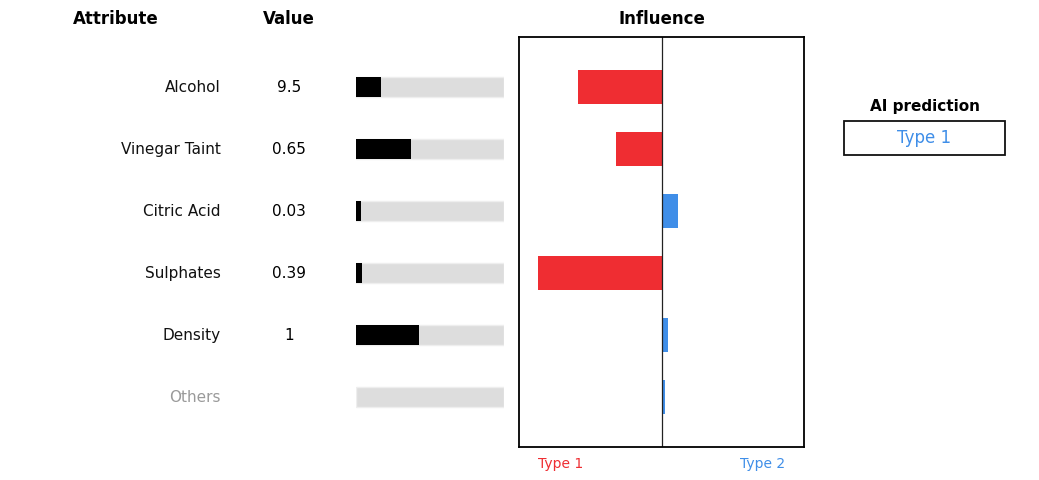

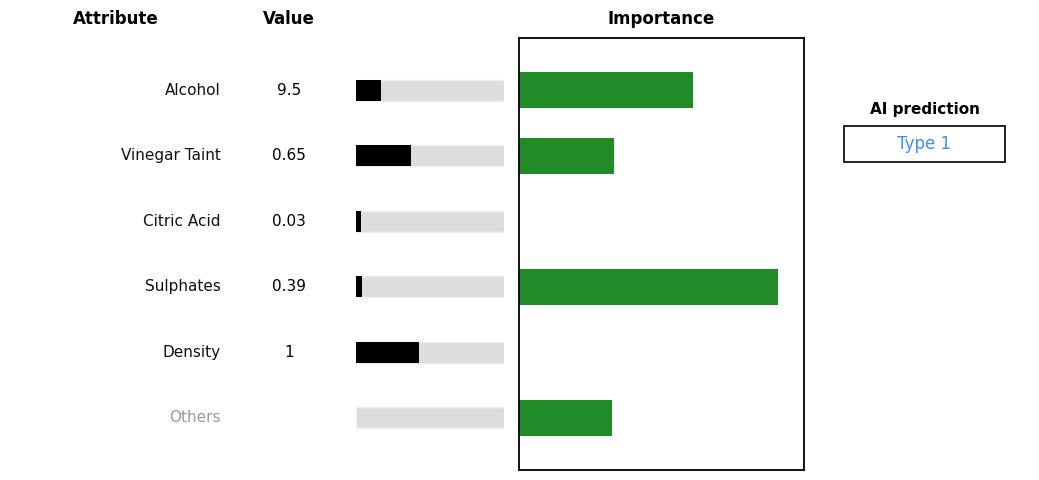

In [10]:
# Step 5.4: visualize generated explanations.
# Influence is the default view: signed attributions show which class each feature pushes toward.
plot_explanation_visual(
    combined_df,  # Combined explanation table from Step 5.3.
    data,  # Prepared dataset; supplies raw feature values for the Value column and mini bars.
    visualization="influence",  # Default view: signed influence toward Type 1 or Type 2.
    method="shap",  # Explanation method to visualize.
    instance_id=data.test_instance_ids[0],  # Choose one trial/test instance to inspect.
    feature_names=data.feature_names,  # Human-readable feature labels.
    top_n=5,  # Show the first 5 predefined features plus an Others row.
    class_labels=["Type 1", "Type 2"],  # Labels shown below influence and in the AI prediction box.
)

# Importance view: class-supporting attributions for the predicted class.
plot_explanation_visual(
    combined_df,  # Combined explanation table from Step 5.3.
    data,  # Prepared dataset for raw feature values.
    visualization="importance",  # Class-supporting importance: pred=0 keeps negative attributions as magnitudes; pred=1 keeps positive attributions.
    method="shap",  # Explanation method to visualize.
    instance_id=data.test_instance_ids[0],  # Same instance as the influence plot for comparison.
    feature_names=data.feature_names,  # Human-readable feature labels.
    top_n=5,  # Show the first 5 predefined features plus an Others row.
    class_labels=["Type 1", "Type 2"],  # Used for the AI prediction label.
)


## 6. Optional: Convert UI JSON to Trial Info

Use this when the experimental-design UI exports a JSON template and you want the notebook to regenerate trial files from it.


In [11]:
# Step 6: optional UI-config path.
# Use this only when the experiment-design UI has exported a JSON template you want to regenerate.
ui_trial_result = generate_trials_from_ui_json(
    "../src/experiment_design/example_json_from_ui/template.json",  # UI-exported JSON config path.
)


Converted UI config into 750 trial rows.
  CSV     : experiment_output/trials.csv
  JSON    : experiment_output/trials.json
  Summary : experiment_output/design_summary.json


## 7. Run Cognitive Simulation

Use CoXAM-style cognitive parameter names with the current placeholder model.


### 7.1 Load Simulation Inputs

Load the explanation pool and declare cognitive parameters using names from the current cognitive artifacts.


In [12]:
# Step 7.1: load simulation inputs.
# The explanation pool links generated explanation rows to trial rows during cognitive simulation.
explanation_pool = load_explanation_pool(
    combined_path  # Combined explanation CSV from Step 5.3.
)

# Start from defaults, then override values that should be explicit in the tutorial.
cognitive_params = default_cognitive_params()
cognitive_params.update({
    "cog_retrieval_threshold": -0.3,  # Memory retrieval threshold; lower values make retrieval easier.
    "cog_latency_factor": 0.2,  # Scales retrieval/action latency in simulated task time.
    "cog_T_enc": 1.5,  # Encoding time component.
    "cog_T_op": 0.5,  # Operation/decision time component.
    "cog_ddm_a": 0.8,  # Drift-diffusion boundary parameter used in accuracy/time placeholder logic.
    "cog_ddm_s": 1.0,  # Drift-diffusion noise/scale parameter used in placeholder logic.
    "cog_chi": 0.001,  # Small bias/adjustment term in the placeholder cognitive model.
    "lapse": 0.005,  # Lower/upper clipping margin for simulated correctness probabilities.
})

# Display the final parameter dictionary for inspection.
cognitive_params


{'cog_retrieval_threshold': -0.3,
 'cog_latency_factor': 0.2,
 'cog_T_enc': 1.5,
 'cog_T_op': 0.5,
 'cog_ddm_a': 0.8,
 'cog_ddm_s': 1.0,
 'cog_chi': 0.001,
 'lapse': 0.005}

### 7.2 Execute a Participant Preview

Run one participant first to verify the cognitive executor output shape.


In [13]:
# Step 7.2: run a one-participant preview before simulating/exporting everything.
# This makes it easier to inspect output shape and values before committing to the full run.
executed = run_experiment_executor(
    trials,  # Trial schedule generated in Step 3.
    cognitive_params=cognitive_params,  # Cognitive-model parameters from Step 7.1.
    dvs=DVs,  # Dependent variables to emit as simulation outputs.
    raw_dataset=data.df,  # Raw feature/label table used to look up trial instance details.
    explanation_pool=explanation_pool,  # Explanation rows available for xai_method/tested_w_xai conditions.
    mode="participant_by_participant",  # Preview one participant instead of the whole experiment.
    participant_id=1,  # Participant id to preview.
    label_column=data.label_column,  # Name of the target/label column in data.df.
)
executed.head()  # Display the first few simulated rows.


,participantId,trialId,block,trialWithinBlock,withinCondition,tested_w_xai,xai_method,dataId,instanceId,model_type,...,cog_param_cog_ddm_s,cog_param_cog_chi,cog_param_lapse,accuracy,task_time,prob_correct,pred_time,agent_prediction,ai_prediction,cognitive_correct_vs_ai
0,1,1,1,1,single_condition,False,shap,wine_quality,1049,mlp,...,1.0,0.001,0.005,0.621897,3.377938,0.621897,3.377938,True,0,False
1,1,2,1,2,single_condition,True,shap,wine_quality,911,mlp,...,1.0,0.001,0.005,0.623054,3.401071,0.623054,3.401071,True,0,False
2,1,3,1,3,single_condition,True,shap,wine_quality,353,mlp,...,1.0,0.001,0.005,0.622760,3.395196,0.622760,3.395196,True,1,True
3,1,4,1,4,single_condition,False,shap,wine_quality,688,mlp,...,1.0,0.001,0.005,0.622903,3.398065,0.622903,3.398065,True,0,False
4,1,5,1,5,single_condition,False,shap,wine_quality,1226,mlp,...,1.0,0.001,0.005,0.622488,3.389761,0.622488,3.389761,True,0,False


## 8. Export Simulated Results

Save the cognitive-model outputs for downstream analysis or dashboard use.


In [14]:
# Step 8: save simulated results.
# Reuse the participant preview if it exists; otherwise simulate the full experiment before saving.
if "executed" in globals() and isinstance(executed, pd.DataFrame):
    simulated_results = executed.copy()  # Fast path: save the preview output already generated above.
else:
    simulated_results = run_experiment_executor(
        trials=trials,  # Trial schedule generated in Step 3.
        cognitive_params=cognitive_params,  # Cognitive-model parameters from Step 7.1.
        dvs=DVs,  # Dependent variables to emit.
        raw_dataset=data.df,  # Raw feature/label table for instance lookup.
        explanation_pool=explanation_pool,  # Combined explanation pool from Step 5.3.
        mode="whole_experiment",  # Simulate every generated participant/trial row.
        label_column=data.label_column,  # Target/label column name.
    )

# Persist results for downstream analysis or dashboard use.
sim_csv_path, sim_json_path = save_simulated_results(simulated_results)
print(f"Saved simulated results: {simulated_results.shape}")
print(f"  CSV : {sim_csv_path}")
print(f"  JSON: {sim_json_path}")
simulated_results.head()


Saved simulated results: (10, 41)
  CSV : experiment_output/simulated_results.csv
  JSON: experiment_output/simulated_results.json


,participantId,trialId,block,trialWithinBlock,withinCondition,tested_w_xai,xai_method,dataId,instanceId,model_type,...,cog_param_cog_ddm_s,cog_param_cog_chi,cog_param_lapse,accuracy,task_time,prob_correct,pred_time,agent_prediction,ai_prediction,cognitive_correct_vs_ai
0,1,1,1,1,single_condition,False,shap,wine_quality,1049,mlp,...,1.0,0.001,0.005,0.621897,3.377938,0.621897,3.377938,True,0,False
1,1,2,1,2,single_condition,True,shap,wine_quality,911,mlp,...,1.0,0.001,0.005,0.623054,3.401071,0.623054,3.401071,True,0,False
2,1,3,1,3,single_condition,True,shap,wine_quality,353,mlp,...,1.0,0.001,0.005,0.622760,3.395196,0.622760,3.395196,True,1,True
3,1,4,1,4,single_condition,False,shap,wine_quality,688,mlp,...,1.0,0.001,0.005,0.622903,3.398065,0.622903,3.398065,True,0,False
4,1,5,1,5,single_condition,False,shap,wine_quality,1226,mlp,...,1.0,0.001,0.005,0.622488,3.389761,0.622488,3.389761,True,0,False
